# Breast Ultrasound Tumor Segmentation & Classification

A **multi-task deep learning** framework that jointly:
- **Segments** breast tumors from ultrasound images (binary mask prediction)
- **Classifies** tissue as *benign*, *malignant*, or *normal*

Two architectures are trained and compared on the [BUSI dataset](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset):

| Model | Accuracy | Dice | Pixel Acc | Mean IoU |
|-------|:--------:|:----:|:---------:|:--------:|
| Multi-Task U-Net | 65% | 0.5522 | 0.9232 | 0.6504 |
| **BiFPN Multi-Task U-Net** | **72%** | **0.5094** | **0.9298** | **0.6358** |


## 1. Setup & Imports

In [1]:
import os
import numpy as np
from glob import glob
from collections import defaultdict

import tensorflow as tf
import tensorflow.image as tfi
from tensorflow import keras
from tensorflow.keras.utils import to_categorical, register_keras_serializable
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPool2D, MaxPooling2D, UpSampling2D,
    Dropout, BatchNormalization, Activation,
    Concatenate, Add, concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import MeanIoU

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


2026-06-19 18:02:02.810957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781892123.241370      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781892123.369638      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781892124.442918      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781892124.442960      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781892124.442962      58 computation_placer.cc:177] computation placer alr

## 2. Configuration

In [2]:
# ── Environment auto-detection ────────────────────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/input')

# ── Dataset path ──────────────────────────────────────────────────────────────
if ON_KAGGLE:
    DATASET_DIR = '/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'
else:
    # Update this to your local dataset location
    DATASET_DIR = 'images/input/Dataset_BUSI_with_GT'

# ── Image parameters ──────────────────────────────────────────────────────────
IMG_SIZE = 256

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE  = 16
EPOCHS      = 50
RANDOM_SEED = 42

# Set to True to load an existing saved model instead of retraining
SKIP_IF_CHECKPOINT_EXISTS = True

# ── Model checkpoint paths (saved inside models/) ─────────────────────────────
MODELS_DIR       = 'models'
CHECKPOINT_UNET  = os.path.join(MODELS_DIR, 'best_model_unet_multi.keras')
CHECKPOINT_BIFPN = os.path.join(MODELS_DIR, 'best_model_bifpn_multi.keras')

# ── Post-processing ───────────────────────────────────────────────────────────
SEG_THRESHOLD = 0.5   # binary threshold for segmentation masks

# ── Classification ────────────────────────────────────────────────────────────
NUM_CLASSES = 3
CLASS_NAMES = ['benign', 'malignant', 'normal']  # must match label encoding (0, 1, 2)

# ── Output directories (all created automatically) ────────────────────────────
OUTPUT_DIR  = 'images/output'
RESULTS_DIR = 'results'
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Environment : {'Kaggle GPU' if ON_KAGGLE else 'Local'}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Image size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"Models dir  : {MODELS_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Results dir : {RESULTS_DIR}")


Environment : Kaggle GPU
Dataset dir : /kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
Image size  : 256x256
Models dir  : models
Output dir  : images/output
Results dir : results


In [3]:
import random, sys

# ── Set all global seeds for full reproducibility ─────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── GPU detection ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs available : {len(gpus)}")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — running on CPU")

print(f"\nTensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Python     : {sys.version.split()[0]}")


GPUs available : 2
  /physical_device:GPU:0
  /physical_device:GPU:1

TensorFlow : 2.19.0
NumPy      : 2.4.6
Python     : 3.12.13


In [4]:
# ── Save training configuration to results/training_config.md ─────────────────
config_md = f"""# Training Configuration

## Dataset
- **Name:** Breast Ultrasound Images (BUSI)
- **Source:** [Kaggle](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset)
- **Classes:** {', '.join(CLASS_NAMES)}
- **Split:** 80% train / 20% validation
- **Random seed:** {RANDOM_SEED}

## Preprocessing
- **Image size:** {IMG_SIZE} x {IMG_SIZE}
- **Normalisation:** pixel values / 255 -> [0, 1]
- **Mask channels:** 1 (grayscale binary)

## Training
- **Batch size:** {BATCH_SIZE}
- **Max epochs:** {EPOCHS}
- **Optimizer:** Adam (default lr = 1e-3)
- **Early stopping:** patience = 10 epochs, monitors val_loss
- **Checkpoint:** saves best model only, monitors val_loss

## Loss Functions and Weights
| Head | Loss | Weight |
|------|------|:------:|
| Segmentation | Dice Loss | 1.0 |
| Classification | Categorical Cross-Entropy | 0.5 |

## Post-processing
- **Segmentation threshold:** {SEG_THRESHOLD}

## Model Checkpoints
| Model | Checkpoint |
|-------|-----------|
| Standard Multi-Task U-Net | {CHECKPOINT_UNET} |
| BiFPN Multi-Task U-Net (primary) | {CHECKPOINT_BIFPN} |
"""

config_path = os.path.join(RESULTS_DIR, 'training_config.md')
with open(config_path, 'w') as f:
    f.write(config_md)
print(f"Saved -> {config_path}")


Saved -> results/training_config.md


## 3. Dataset Validation

In [5]:
# Validate the dataset directory before any processing begins
if not os.path.isdir(DATASET_DIR):
    raise FileNotFoundError(
        f"Dataset not found at: '{DATASET_DIR}'\n"
        "  Download from: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset\n"
        "  Then set DATASET_DIR in the Configuration cell."
    )

classes = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d)) and not d.startswith('.')
])

expected_classes = {'benign', 'malignant', 'normal'}
missing = expected_classes - set(classes)
if missing:
    raise ValueError(
        f"Dataset is missing expected class folders: {missing}\n"
        f"Found: {classes}"
    )

print(f"Dataset OK. Classes: {classes}")


Dataset OK. Classes: ['benign', 'malignant', 'normal']


## 4. Dataset Exploration

Class          Images   Max masks/img
--------------------------------------
benign            437               3
malignant         210               2
normal            133               1
--------------------------------------
Total             780


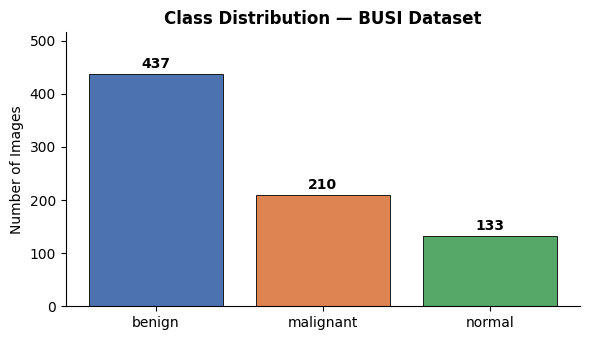

In [6]:
# Count images and masks per class, and find the maximum mask count per image
class_img_counts  = {}
class_mask_counts = defaultdict(int)
overall_max_masks = 0

for cls in classes:
    png_files = glob(os.path.join(DATASET_DIR, cls, "*.png"))

    # Separate raw images from mask files
    imgs  = [f for f in png_files if 'mask' not in os.path.basename(f)]
    class_img_counts[cls] = len(imgs)

    # Count masks per base image within this class
    image_mask_counts = defaultdict(int)
    for file_path in png_files:
        filename = os.path.basename(file_path)
        if 'mask' in filename:
            base_name = filename.split('_mask')[0]
            image_mask_counts[base_name] += 1

    max_masks = max(image_mask_counts.values(), default=0)
    class_mask_counts[cls] = max_masks
    overall_max_masks = max(overall_max_masks, max_masks)

total_images = sum(class_img_counts.values())
print(f"{'Class':<12} {'Images':>8} {'Max masks/img':>15}")
print('-' * 38)
for cls in classes:
    print(f"{cls:<12} {class_img_counts[cls]:>8} {class_mask_counts[cls]:>15}")
print('-' * 38)
print(f"{'Total':<12} {total_images:>8}")

# Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(class_img_counts.keys(), class_img_counts.values(),
              color=colors, edgecolor='black', linewidth=0.6)
for bar, count in zip(bars, class_img_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Class Distribution — BUSI Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, max(class_img_counts.values()) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()


In [7]:
def collect_mask_paths(classes, dataset_dir, suffix):
    """Return sorted list-of-lists of mask paths matching the given filename suffix."""
    paths = []
    for cls in classes:
        pattern = os.path.join(dataset_dir, cls, f"*{suffix}")
        paths.append(sorted(glob(pattern)))
    return sorted(paths)

single_mask_paths = collect_mask_paths(classes, DATASET_DIR, "mask.png")
double_mask_paths = collect_mask_paths(classes, DATASET_DIR, "mask_1.png")
triple_mask_paths = collect_mask_paths(classes, DATASET_DIR, "mask_2.png")

print(f"Images with primary mask   : {sum(len(p) for p in single_mask_paths)}")
print(f"Images with secondary mask : {sum(len(p) for p in double_mask_paths)}")
print(f"Images with tertiary mask  : {sum(len(p) for p in triple_mask_paths)}")
print()
print("Note: Only primary masks are used for training.")
print("Secondary / tertiary masks exist for images with multiple lesions.")


Images with primary mask   : 780
Images with secondary mask : 17
Images with tertiary mask  : 1

Note: Only primary masks are used for training.
Secondary / tertiary masks exist for images with multiple lesions.


## 5. Data Loading & Preprocessing

In [8]:
def load_image(image_path, size):
    """Load a single image, normalise to [0, 1], and resize to (size, size)."""
    try:
        img = load_img(image_path)
    except Exception as exc:
        raise IOError(f"Cannot load image '{image_path}': {exc}") from exc
    img_array = img_to_array(img)
    img_array = img_array / 255.
    img_resized = tfi.resize(img_array, (size, size))
    return np.round(img_resized, 4)


def load_images(image_paths, size, mask=False, trim=None):
    """
    Load a list of image paths into a float32 numpy array.

    Args:
        image_paths: list of file paths
        size:        target height/width (square)
        mask:        if True, keeps only the first channel (grayscale mask)
        trim:        optional limit on how many images to load
    """
    if trim is not None:
        image_paths = image_paths[:trim]

    channels = 1 if mask else 3
    out = np.zeros((len(image_paths), size, size, channels), dtype=np.float32)

    for i, path in enumerate(image_paths):
        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: '{path}'")
        img = load_image(path, size)
        out[i] = img[:, :, :channels]
        if (i + 1) % 100 == 0 or (i + 1) == len(image_paths):
            print(f"\r  {i + 1}/{len(image_paths)} loaded", end="", flush=True)

    print()  # newline after progress
    return out


In [9]:
# Build aligned lists of (image_path, mask_path, label) from primary masks only
image_paths = []
mask_paths  = []
labels      = []

for class_masks in single_mask_paths:
    for mask_path in class_masks:
        img_path = mask_path.replace('_mask', '')
        image_paths.append(img_path)
        mask_paths.append(mask_path)

        if 'benign' in mask_path.lower():
            labels.append(0)
        elif 'malignant' in mask_path.lower():
            labels.append(1)
        elif 'normal' in mask_path.lower():
            labels.append(2)
        else:
            raise ValueError(f"Cannot determine class from path: '{mask_path}'")

labels = to_categorical(labels, num_classes=NUM_CLASSES)

print(f"Total paired samples : {len(image_paths)}")
print(f"  Benign    (0) : {int(labels[:, 0].sum())}")
print(f"  Malignant (1) : {int(labels[:, 1].sum())}")
print(f"  Normal    (2) : {int(labels[:, 2].sum())}")


Total paired samples : 780
  Benign    (0) : 437
  Malignant (1) : 210
  Normal    (2) : 133


In [10]:
print("Loading images...")
images = load_images(image_paths, IMG_SIZE)

print("Loading masks...")
masks = load_images(mask_paths, IMG_SIZE, mask=True)

print(f"Images : {images.shape}  dtype={images.dtype}")
print(f"Masks  : {masks.shape}  dtype={masks.dtype}")


Loading images...


I0000 00:00:1781892193.237126      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781892193.242970      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  780/780 loaded
Loading masks...
  780/780 loaded
Images : (780, 256, 256, 3)  dtype=float32
Masks  : (780, 256, 256, 1)  dtype=float32


## 6. Visualization

In [11]:
def show_image(image, title=None, cmap=None, alpha=1):
    plt.imshow(image, cmap=cmap, alpha=alpha)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.axis('off')


def show_mask(image, mask, cmap='jet', alpha=0.4):
    """Overlay a segmentation mask on top of the original image."""
    plt.imshow(image)
    plt.imshow(tf.squeeze(mask), cmap=cmap, alpha=alpha)
    plt.axis('off')


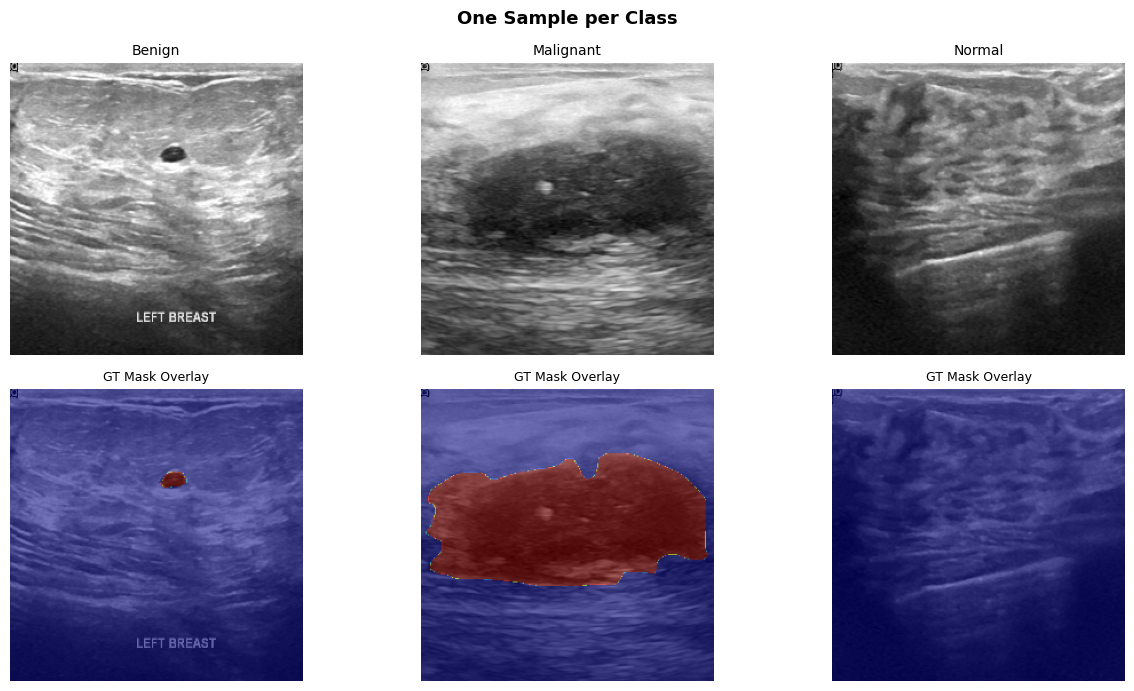

In [12]:
# Show one representative sample from each class (image + mask overlay)
label_array = np.argmax(labels, axis=1)
class_indices = {name: np.where(label_array == i)[0] for i, name in enumerate(CLASS_NAMES)}

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(13, 7))
for col, name in enumerate(CLASS_NAMES):
    idx = class_indices[name][0]

    plt.sca(axes[0, col])
    show_image(images[idx], title=f"{name.capitalize()}")

    plt.sca(axes[1, col])
    show_mask(images[idx], masks[idx], alpha=0.55)
    plt.title("GT Mask Overlay", fontsize=9)

axes[0, 0].set_ylabel("Original Image", fontsize=10)
axes[1, 0].set_ylabel("Mask Overlay",   fontsize=10)
plt.suptitle("One Sample per Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_per_class.png'), dpi=120, bbox_inches='tight')
plt.show()


## 7. Model Architecture

### 7.1 Standard Multi-Task U-Net

Classic encoder-decoder U-Net extended with a **classification head** attached to the bottleneck.
The segmentation decoder uses skip connections from every encoder stage to preserve fine spatial detail.

```
Input (256×256×3)
  └─ Encoder: 64 → 128 → 256 → 512 (4× MaxPool)
       └─ Bottleneck: 1024 (Dropout 0.3)
            ├─ Seg Decoder: 512 → 256 → 128 → 64 → Conv2D(1) sigmoid
            └─ Cls Head:    GAP → Dense(256) → Dense(3) softmax
```


In [13]:
def conv_block(x, filters, dropout=False):
    x = Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    if dropout:
        x = Dropout(0.3)(x)
    x = Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    return x


def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = MaxPool2D((2, 2))(c)
    return c, p


def decoder_block(x, skip, filters):
    us = UpSampling2D((2, 2))(x)
    concat = concatenate([us, skip])
    return conv_block(concat, filters)


def build_multi_task_unet(input_shape=(256, 256, 3), num_classes=3):
    inputs = Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b = conv_block(p4, 1024, dropout=True)

    # Decoder — segmentation head
    d1 = decoder_block(b,  s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    seg_output = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(d4)

    # Classification head attached to the bottleneck
    cls_pool   = tf.keras.layers.GlobalAveragePooling2D()(b)
    cls_dense  = tf.keras.layers.Dense(256, activation='relu')(cls_pool)
    cls_output = tf.keras.layers.Dense(num_classes, activation='softmax', name='classification')(cls_dense)

    return Model(inputs=inputs, outputs={"segmentation": seg_output, "classification": cls_output})


### 7.2 BiFPN Multi-Task U-Net

Replaces the standard decoder with a **Bidirectional Feature Pyramid Network (BiFPN)** that fuses
encoder features both top-down and bottom-up before decoding. The classification head is attached to
the richer `P5_out` feature map rather than the raw bottleneck.

```
Encoder (same as U-Net)
  └─ BiFPN: top-down  P6→P5→P4→P3
             bottom-up P3→P4→P5
       ├─ Seg Decoder: P3_td → UpSample → concat(s1) → Conv2D(1) sigmoid
       └─ Cls Head:    P5_out → GAP → Dense(256) → Dense(3) softmax
```


In [15]:
def build_multi_task_unet_bifpn(input_shape=(256, 256, 3), num_classes=3):
    inputs = Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)    # 256 × 256
    s2, p2 = encoder_block(p1, 128)       # 128 × 128
    s3, p3 = encoder_block(p2, 256)       # 64  × 64
    s4, p4 = encoder_block(p3, 512)       # 32  × 32

    # Bottleneck
    b = conv_block(p4, 1024, dropout=True)  # 16 × 16

    # ── Helper conv ───────────────────────────────────────────────────────────
    def conv_bn_relu(x, filters, name):
        x = Conv2D(filters, (3, 3), padding='same', name=name + '_conv')(x)
        x = BatchNormalization(name=name + '_bn')(x)
        x = Activation('relu', name=name + '_act')(x)
        return x

    # ── BiFPN block ───────────────────────────────────────────────────────────
    def bifpn_block(P3, P4, P5, P6, filters):
        # Project all feature maps to the same channel depth
        P3 = Conv2D(filters, (1, 1), padding='same')(P3)  # 128 × 128
        P4 = Conv2D(filters, (1, 1), padding='same')(P4)  # 64  × 64
        P5 = Conv2D(filters, (1, 1), padding='same')(P5)  # 32  × 32
        P6 = Conv2D(filters, (1, 1), padding='same')(P6)  # 16  × 16

        # Top-down pass (coarse → fine)
        P6_up  = UpSampling2D()(P6)
        P5_td  = conv_bn_relu(Add()([P5, P6_up]), filters, 'P5_td')

        P5_up  = UpSampling2D()(P5_td)
        P4_td  = conv_bn_relu(Add()([P4, P5_up]), filters, 'P4_td')

        P4_up  = UpSampling2D()(P4_td)
        P3_td  = conv_bn_relu(Add()([P3, P4_up]), filters, 'P3_td')

        # Bottom-up pass (fine → coarse)
        P3_dn  = MaxPool2D()(P3_td)
        P4_out = conv_bn_relu(Add()([P4_td, P3_dn]), filters, 'P4_out')

        P4_dn  = MaxPool2D()(P4_out)
        P5_out = conv_bn_relu(Add()([P5_td, P4_dn]), filters, 'P5_out')

        return P3_td, P4_out, P5_out

    # Wire encoder features into BiFPN (bottleneck b acts as P6)
    P3, P4, P5, P6         = s2, s3, s4, b
    P3_td, P4_out, P5_out  = bifpn_block(P3, P4, P5, P6, filters=256)

    # Decoder — segmentation head
    x = UpSampling2D()(P3_td)
    x = conv_bn_relu(x, 128, 'up1')
    x = tf.keras.layers.Concatenate()([x, s1])
    x = conv_bn_relu(x, 64, 'up2')
    x = conv_bn_relu(x, 32, 'up3')
    seg_output = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(x)

    # Classification head — uses BiFPN-fused P5 features
    cls_pool   = tf.keras.layers.GlobalAveragePooling2D()(P5_out)
    cls_dense  = tf.keras.layers.Dense(256, activation='relu')(cls_pool)
    cls_output = tf.keras.layers.Dense(num_classes, activation='softmax', name='classification')(cls_dense)

    return Model(inputs, outputs={"segmentation": seg_output, "classification": cls_output})


## 8. Loss Functions & Metrics

| Head | Loss | Weight |
|------|------|--------|
| Segmentation | Dice Loss (handles foreground/background imbalance) | 1.0 |
| Classification | Categorical Cross-Entropy | 0.5 |


In [16]:
@register_keras_serializable()
def dice_loss(y_true, y_pred):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + 1) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + 1
    )


LOSSES = {
    "segmentation":   dice_loss,
    "classification": "categorical_crossentropy",
}

LOSS_WEIGHTS = {
    "segmentation":   1.0,
    "classification": 0.5,
}

METRICS = {
    "segmentation":   [MeanIoU(num_classes=2)],
    "classification": ["accuracy"],
}


## 9. Training

### 9.1 Train / Validation Split

In [17]:
train_imgs, val_imgs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    images, masks, labels,
    test_size=0.2,
    random_state=RANDOM_SEED,
)
print(f"Training   : {len(train_imgs)} samples")
print(f"Validation : {len(val_imgs)} samples")


Training   : 624 samples
Validation : 156 samples


### 9.2 Standard Multi-Task U-Net

In [ ]:
if SKIP_IF_CHECKPOINT_EXISTS and os.path.exists(CHECKPOINT_UNET):
    print(f"[INFO] Checkpoint found: '{CHECKPOINT_UNET}'. Loading saved model.")
    model = keras.models.load_model(CHECKPOINT_UNET, custom_objects={'dice_loss': dice_loss})
    history_unet = None
else:
    model = build_multi_task_unet()
    model.compile(
        optimizer='adam',
        loss=LOSSES,
        loss_weights=LOSS_WEIGHTS,
        metrics=METRICS,
    )
    callbacks_unet = [
        ModelCheckpoint(CHECKPOINT_UNET, save_best_only=True, monitor='val_loss'),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ]
    history_unet = model.fit(
        x=train_imgs,
        y={"segmentation": train_masks, "classification": train_labels},
        validation_data=(val_imgs, {"segmentation": val_masks, "classification": val_labels}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_unet,
    )


Epoch 1/50


I0000 00:00:1781892298.054468     134 service.cc:152] XLA service 0x78ce240019d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781892298.054516     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781892298.054523     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781892300.343147     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-19 18:05:33.774894: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:05:34.100193: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.19 = (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0} %bitcast.26317, f32[128,128,3,3]{3,2,1,0} %bitc

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - classification_accuracy: 0.4651 - classification_loss: 1.8038 - loss: 1.7412 - segmentation_loss: 0.8393 - segmentation_mean_io_u: 0.4728

2026-06-19 18:07:37.704559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:07:37.935359: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:07:39.287138: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:07:39.600290: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


39/39 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - classification_accuracy: 0.5064 - classification_loss: 1.4441 - loss: 1.5256 - segmentation_loss: 0.8035 - segmentation_mean_io_u: 0.4902 - val_classification_accuracy: 0.5385 - val_classification_loss: 68.4546 - val_loss: 35.2277 - val_segmentation_loss: 0.8566 - val_segmentation_mean_io_u: 0.0733
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 39s 996ms/step - classification_accuracy: 0.5433 - classification_loss: 1.0950 - loss: 1.2583 - segmentation_loss: 0.7108 - segmentation_mean_io_u: 0.5544 - val_classification_accuracy: 0.4038 - val_classification_loss: 6.9404 - val_loss: 4.3328 - val_segmentation_loss: 0.8229 - val_segmentation_mean_io_u: 0.2626
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 37s 948ms/step - classification_accuracy: 0.5833 - classification_loss: 0.9780 - loss: 1.1319 - segmentation_loss: 0.6429 - segmentation_mean_io_u: 0.5769 - val_classification_accuracy: 0.1795 - val_classification_loss: 10.5736 - val_loss: 6.1317 - val_segmentation_l

### 9.3 BiFPN Multi-Task U-Net

In [19]:
if SKIP_IF_CHECKPOINT_EXISTS and os.path.exists(CHECKPOINT_BIFPN):
    print(f"[INFO] Checkpoint found: '{CHECKPOINT_BIFPN}'. Loading saved model.")
    model2 = keras.models.load_model(CHECKPOINT_BIFPN, custom_objects={'dice_loss': dice_loss})
    history_bifpn = None
else:
    model2 = build_multi_task_unet_bifpn()
    model2.compile(
        optimizer='adam',
        loss=LOSSES,
        loss_weights=LOSS_WEIGHTS,
        metrics=METRICS,
    )
    callbacks_bifpn = [
        ModelCheckpoint(CHECKPOINT_BIFPN, save_best_only=True, monitor='val_loss'),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ]
    history_bifpn = model2.fit(
        x=train_imgs,
        y={"segmentation": train_masks, "classification": train_labels},
        validation_data=(val_imgs, {"segmentation": val_masks, "classification": val_labels}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_bifpn,
    )


Epoch 1/50


2026-06-19 18:30:03.447882: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv %cudnn-conv-bias-activation.94 = (f32[16,128,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,256,256,256]{3,2,1,0} %bitcast.21762, f32[128,256,3,3]{3,2,1,0} %bitcast.21769, f32[128]{0} %bitcast.28013), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1_1/up1_conv_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-19 18:30:03.463834: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.016146306s
Tr

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - classification_accuracy: 0.5395 - classification_loss: 1.0231 - loss: 1.3423 - segmentation_loss: 0.8308 - segmentation_mean_io_u: 0.5640

2026-06-19 18:31:35.412083: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:31:35.726751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:31:36.396007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:31:36.626356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


39/39 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - classification_accuracy: 0.5705 - classification_loss: 0.9417 - loss: 1.2709 - segmentation_loss: 0.8000 - segmentation_mean_io_u: 0.5212 - val_classification_accuracy: 0.5385 - val_classification_loss: 6.6301 - val_loss: 4.2165 - val_segmentation_loss: 0.8581 - val_segmentation_mean_io_u: 0.0884
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - classification_accuracy: 0.6394 - classification_loss: 0.8339 - loss: 1.1021 - segmentation_loss: 0.6851 - segmentation_mean_io_u: 0.4884 - val_classification_accuracy: 0.2756 - val_classification_loss: 7.4679 - val_loss: 4.6048 - val_segmentation_loss: 0.8474 - val_segmentation_mean_io_u: 0.1801
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - classification_accuracy: 0.7099 - classification_loss: 0.6998 - loss: 0.9186 - segmentation_loss: 0.5687 - segmentation_mean_io_u: 0.5100 - val_classification_accuracy: 0.2756 - val_classification_loss: 57.6027 - val_loss: 29.7368 - val_segmentation_loss: 0.

In [20]:
import json as _json

def save_history(history, path):
    """Serialise a Keras History object to JSON (numpy floats -> Python floats)."""
    serialisable = {k: [float(v) for v in vals]
                    for k, vals in history.history.items()}
    with open(path, 'w') as f:
        _json.dump(serialisable, f, indent=2)
    epochs_run = len(next(iter(serialisable.values())))
    print(f"Saved -> {path}  ({epochs_run} epochs)")

if history_unet is not None:
    save_history(history_unet,  os.path.join(RESULTS_DIR, 'history_unet.json'))
else:
    print("[INFO] U-Net loaded from checkpoint — no training history to save.")

if history_bifpn is not None:
    save_history(history_bifpn, os.path.join(RESULTS_DIR, 'history_bifpn.json'))
else:
    print("[INFO] BiFPN loaded from checkpoint — no training history to save.")


Saved -> results/history_unet.json  (28 epochs)
Saved -> results/history_bifpn.json  (30 epochs)


### 9.4 Training Curves

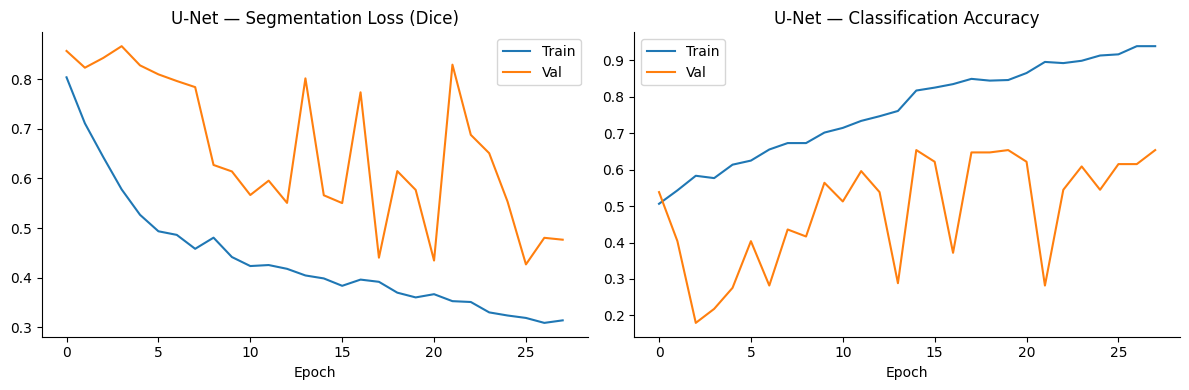

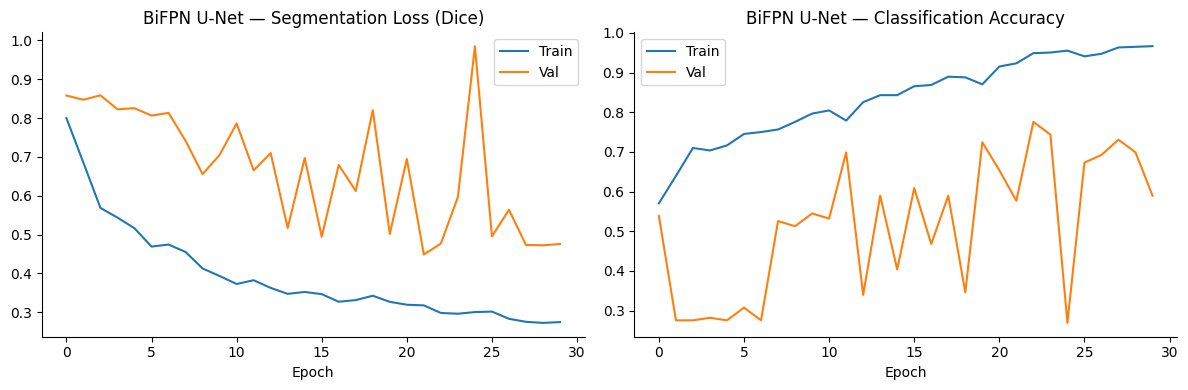

In [21]:
def plot_history(history, title_prefix="", save_path=None):
    """Plot segmentation loss and classification accuracy from a training history."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['segmentation_loss'],     label='Train', linewidth=1.5)
    axes[0].plot(history.history['val_segmentation_loss'], label='Val',   linewidth=1.5)
    axes[0].set_title(f'{title_prefix} — Segmentation Loss (Dice)')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    axes[1].plot(history.history['classification_accuracy'],     label='Train', linewidth=1.5)
    axes[1].plot(history.history['val_classification_accuracy'], label='Val',   linewidth=1.5)
    axes[1].set_title(f'{title_prefix} — Classification Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


if history_unet is not None:
    plot_history(history_unet,  title_prefix="U-Net",
                 save_path=os.path.join(RESULTS_DIR, 'training_curves_unet.png'))
else:
    print("[INFO] U-Net was loaded from checkpoint — no training history available.")

if history_bifpn is not None:
    plot_history(history_bifpn, title_prefix="BiFPN U-Net",
                 save_path=os.path.join(RESULTS_DIR, 'training_curves_bifpn.png'))
else:
    print("[INFO] BiFPN U-Net was loaded from checkpoint — no training history available.")


## 10. Evaluation

In [22]:
def evaluate_model(model, X, y_masks, y_labels, model_name="Model"):
    """
    Run a single forward pass and report both segmentation and classification metrics.
    Returns the raw predictions dict for downstream use.
    """
    preds = model.predict(X, batch_size=BATCH_SIZE, verbose=0)

    # ── Classification ────────────────────────────────────────────────────────
    y_pred_cls = np.argmax(preds["classification"], axis=1)
    y_true_cls = np.argmax(y_labels, axis=1)

    print(f"\n{'═' * 50}")
    print(f"  {model_name}")
    print(f"{'═' * 50}")
    print("\nClassification Report:")
    print(classification_report(y_true_cls, y_pred_cls, target_names=CLASS_NAMES))

    # ── Segmentation ──────────────────────────────────────────────────────────
    y_pred_seg = (preds["segmentation"] > SEG_THRESHOLD).astype(np.uint8)

    smooth       = 1e-6
    intersection = np.sum(y_pred_seg * y_masks)
    union        = np.sum(y_pred_seg) + np.sum(y_masks)
    dice         = (2. * intersection + smooth) / (union + smooth)
    pixel_acc    = np.mean(y_pred_seg == y_masks)

    iou_metric = MeanIoU(num_classes=2)
    iou_metric.update_state(y_masks, y_pred_seg)
    mean_iou = iou_metric.result().numpy()

    print("Segmentation Metrics:")
    print(f"  Dice Coefficient : {dice:.4f}")
    print(f"  Pixel Accuracy   : {pixel_acc:.4f}")
    print(f"  Mean IoU         : {mean_iou:.4f}")

    return preds, y_pred_cls, y_true_cls


### 10.1 Standard U-Net


══════════════════════════════════════════════════
  Standard Multi-Task U-Net
══════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

      benign       0.69      0.79      0.74        84
   malignant       0.64      0.65      0.64        43
      normal       0.41      0.24      0.30        29

    accuracy                           0.65       156
   macro avg       0.58      0.56      0.56       156
weighted avg       0.63      0.65      0.63       156

Segmentation Metrics:
  Dice Coefficient : 0.5522
  Pixel Accuracy   : 0.9232
  Mean IoU         : 0.6504


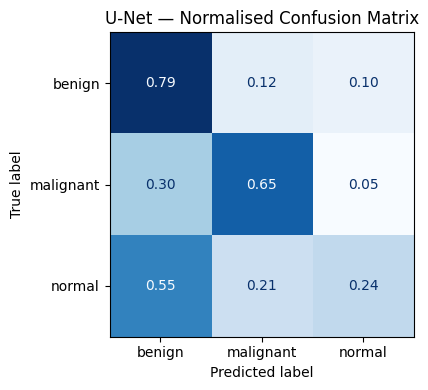

In [23]:
preds_unet, y_pred_unet, y_true_unet = evaluate_model(
    model, val_imgs, val_masks, val_labels, model_name="Standard Multi-Task U-Net"
)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_true_unet, y_pred_unet, normalize='true'),
    display_labels=CLASS_NAMES
).plot(ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
ax.set_title("U-Net — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_unet.png'), dpi=120, bbox_inches='tight')
plt.show()


### 10.2 BiFPN U-Net


══════════════════════════════════════════════════
  BiFPN Multi-Task U-Net
══════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

      benign       0.72      0.87      0.78        84
   malignant       0.79      0.35      0.48        43
      normal       0.71      0.86      0.78        29

    accuracy                           0.72       156
   macro avg       0.74      0.69      0.68       156
weighted avg       0.74      0.72      0.70       156

Segmentation Metrics:
  Dice Coefficient : 0.5094
  Pixel Accuracy   : 0.9298
  Mean IoU         : 0.6358


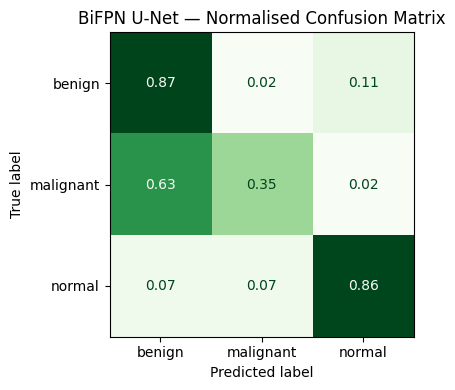

In [24]:
preds_bifpn, y_pred_bifpn, y_true_bifpn = evaluate_model(
    model2, val_imgs, val_masks, val_labels, model_name="BiFPN Multi-Task U-Net"
)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_true_bifpn, y_pred_bifpn, normalize='true'),
    display_labels=CLASS_NAMES
).plot(ax=ax, cmap='Greens', colorbar=False, values_format='.2f')
ax.set_title("BiFPN U-Net — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_bifpn.png'), dpi=120, bbox_inches='tight')
plt.show()


In [25]:
import io as _io

def save_model_summary(model, model_name, path):
    """Write model.summary() output to a plain-text file."""
    buf = _io.StringIO()
    model.summary(print_fn=lambda line: buf.write(line + '\n'))
    total_params = model.count_params()
    with open(path, 'w') as f:
        f.write(f"Model      : {model_name}\n")
        f.write(f"Parameters : {total_params:,}\n")
        f.write('=' * 65 + '\n')
        f.write(buf.getvalue())
    print(f"Saved -> {path}  ({total_params:,} parameters)")

save_model_summary(model,  "Standard Multi-Task U-Net",
                   os.path.join(RESULTS_DIR, 'model_summary_unet.txt'))

save_model_summary(model2, "BiFPN Multi-Task U-Net",
                   os.path.join(RESULTS_DIR, 'model_summary_bifpn.txt'))


Saved -> results/model_summary_unet.txt  (31,665,668 parameters)


Saved -> results/model_summary_bifpn.txt  (22,798,788 parameters)


In [26]:
def save_cls_report(y_true, y_pred, model_name, path):
    """Write a full sklearn classification_report to a text file."""
    report = classification_report(y_true, y_pred,
                                   target_names=CLASS_NAMES, digits=4)
    with open(path, 'w') as f:
        f.write(f"Model: {model_name}\n")
        f.write('=' * 60 + '\n\n')
        f.write(report)
    print(f"Saved -> {path}")

save_cls_report(y_true_unet,  y_pred_unet,
                "Standard Multi-Task U-Net",
                os.path.join(RESULTS_DIR, 'classification_report_unet.txt'))

save_cls_report(y_true_bifpn, y_pred_bifpn,
                "BiFPN Multi-Task U-Net",
                os.path.join(RESULTS_DIR, 'classification_report_bifpn.txt'))


Saved -> results/classification_report_unet.txt
Saved -> results/classification_report_bifpn.txt


In [27]:
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, accuracy_score,
                             classification_report as _cls_report)

# ── Compute seg metrics from pre-computed predictions (no second forward pass) ─
def seg_metrics_from_preds(preds, y_masks):
    """Dice, pixel accuracy, Mean IoU from a predictions dict."""
    y_pred = (preds["segmentation"] > SEG_THRESHOLD).astype(np.uint8)
    smooth = 1e-6
    inter  = np.sum(y_pred * y_masks)
    union  = np.sum(y_pred) + np.sum(y_masks)
    dice   = (2. * inter + smooth) / (union + smooth)
    pix    = np.mean(y_pred == y_masks)
    iou_m  = MeanIoU(num_classes=2)
    iou_m.update_state(y_masks, y_pred)
    return dice, pix, iou_m.result().numpy()

def cls_metrics(y_true, y_pred):
    """Return accuracy, macro precision/recall/F1 as a dict."""
    return dict(
        accuracy  = accuracy_score( y_true, y_pred),
        precision = precision_score(y_true, y_pred, average="macro", zero_division=0),
        recall    = recall_score(   y_true, y_pred, average="macro", zero_division=0),
        f1        = f1_score(       y_true, y_pred, average="macro", zero_division=0),
    )

# Compute — uses preds_unet / preds_bifpn already in memory
dice_u, pix_u, iou_u = seg_metrics_from_preds(preds_unet,  val_masks)
dice_b, pix_b, iou_b = seg_metrics_from_preds(preds_bifpn, val_masks)
cls_u = cls_metrics(y_true_unet,  y_pred_unet)
cls_b = cls_metrics(y_true_bifpn, y_pred_bifpn)

# ── results/metrics.md ────────────────────────────────────────────────────────
metrics_md_text = f'''# Experiment Results

**Dataset:** Breast Ultrasound Images (BUSI)
**Split:** 80% train / 20% validation
**Image size:** {IMG_SIZE}x{IMG_SIZE}
**Random seed:** {RANDOM_SEED}

---

## Classification Metrics (Validation Set)

| Model | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|-------|:--------:|:-----------------:|:--------------:|:----------:|
| Multi-Task U-Net | {cls_u["accuracy"]:.4f} | {cls_u["precision"]:.4f} | {cls_u["recall"]:.4f} | {cls_u["f1"]:.4f} |
| **BiFPN Multi-Task U-Net** | **{cls_b["accuracy"]:.4f}** | **{cls_b["precision"]:.4f}** | **{cls_b["recall"]:.4f}** | **{cls_b["f1"]:.4f}** |

## Segmentation Metrics (Validation Set)

| Model | Dice Coefficient | Pixel Accuracy | Mean IoU |
|-------|:---------------:|:--------------:|:--------:|
| Multi-Task U-Net | {dice_u:.4f} | {pix_u:.4f} | {iou_u:.4f} |
| **BiFPN Multi-Task U-Net** | **{dice_b:.4f}** | **{pix_b:.4f}** | **{iou_b:.4f}** |

---

## Label Encoding
| Index | Class |
|:-----:|-------|
| 0 | benign |
| 1 | malignant |
| 2 | normal |

## Notes
- Segmentation threshold: {SEG_THRESHOLD}
- Dice loss: 1 - (2*intersection + 1) / (sum_true + sum_pred + 1)
- Loss weights: segmentation x 1.0, classification x 0.5
'''

with open(os.path.join(RESULTS_DIR, "metrics.md"), "w") as f:
    f.write(metrics_md_text)
print(f"Saved -> {os.path.join(RESULTS_DIR, 'metrics.md')}")

# ── results/best_validation_metrics.md (BiFPN is the primary model) ───────────
per_class = _cls_report(y_true_bifpn, y_pred_bifpn,
                         target_names=CLASS_NAMES, digits=4)

best_md_text = f'''# Best Model - Validation Results

**Model:** BiFPN Multi-Task U-Net
**Dataset:** Breast Ultrasound Images (BUSI) - validation split (20%)
**Checkpoint:** {CHECKPOINT_BIFPN}

---

## Classification

| Metric | Value |
|--------|:-----:|
| Accuracy | {cls_b["accuracy"]:.4f} ({cls_b["accuracy"]:.1%}) |
| Precision (macro) | {cls_b["precision"]:.4f} |
| Recall (macro) | {cls_b["recall"]:.4f} |
| F1-score (macro) | {cls_b["f1"]:.4f} |

### Per-Class Detail

{per_class}

## Segmentation

| Metric | Value |
|--------|:-----:|
| Dice Coefficient | {dice_b:.4f} |
| Pixel Accuracy | {pix_b:.4f} ({pix_b:.1%}) |
| Mean IoU | {iou_b:.4f} |

---

## Comparison vs Baseline (Standard U-Net)

| Metric | U-Net | BiFPN U-Net | Change |
|--------|:-----:|:-----------:|:------:|
| Accuracy | {cls_u["accuracy"]:.4f} | {cls_b["accuracy"]:.4f} | {cls_b["accuracy"]-cls_u["accuracy"]:+.4f} |
| Precision (macro) | {cls_u["precision"]:.4f} | {cls_b["precision"]:.4f} | {cls_b["precision"]-cls_u["precision"]:+.4f} |
| Recall (macro) | {cls_u["recall"]:.4f} | {cls_b["recall"]:.4f} | {cls_b["recall"]-cls_u["recall"]:+.4f} |
| F1 (macro) | {cls_u["f1"]:.4f} | {cls_b["f1"]:.4f} | {cls_b["f1"]-cls_u["f1"]:+.4f} |
| Dice | {dice_u:.4f} | {dice_b:.4f} | {dice_b-dice_u:+.4f} |
| Pixel Accuracy | {pix_u:.4f} | {pix_b:.4f} | {pix_b-pix_u:+.4f} |
| Mean IoU | {iou_u:.4f} | {iou_b:.4f} | {iou_b-iou_u:+.4f} |
'''

with open(os.path.join(RESULTS_DIR, "best_validation_metrics.md"), "w") as f:
    f.write(best_md_text)
print(f"Saved -> {os.path.join(RESULTS_DIR, 'best_validation_metrics.md')}")


Saved -> results/metrics.md
Saved -> results/best_validation_metrics.md


## 11. Prediction Visualization

Each row: **Ground-Truth Mask** | **Raw Predicted Mask** | **Thresholded Binary Mask** (> 0.5)


2026-06-19 18:56:13.282779: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:56:13.504364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:56:13.734274: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:56:13.963593: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:56:13.989329: E external/local_xla/xla/service

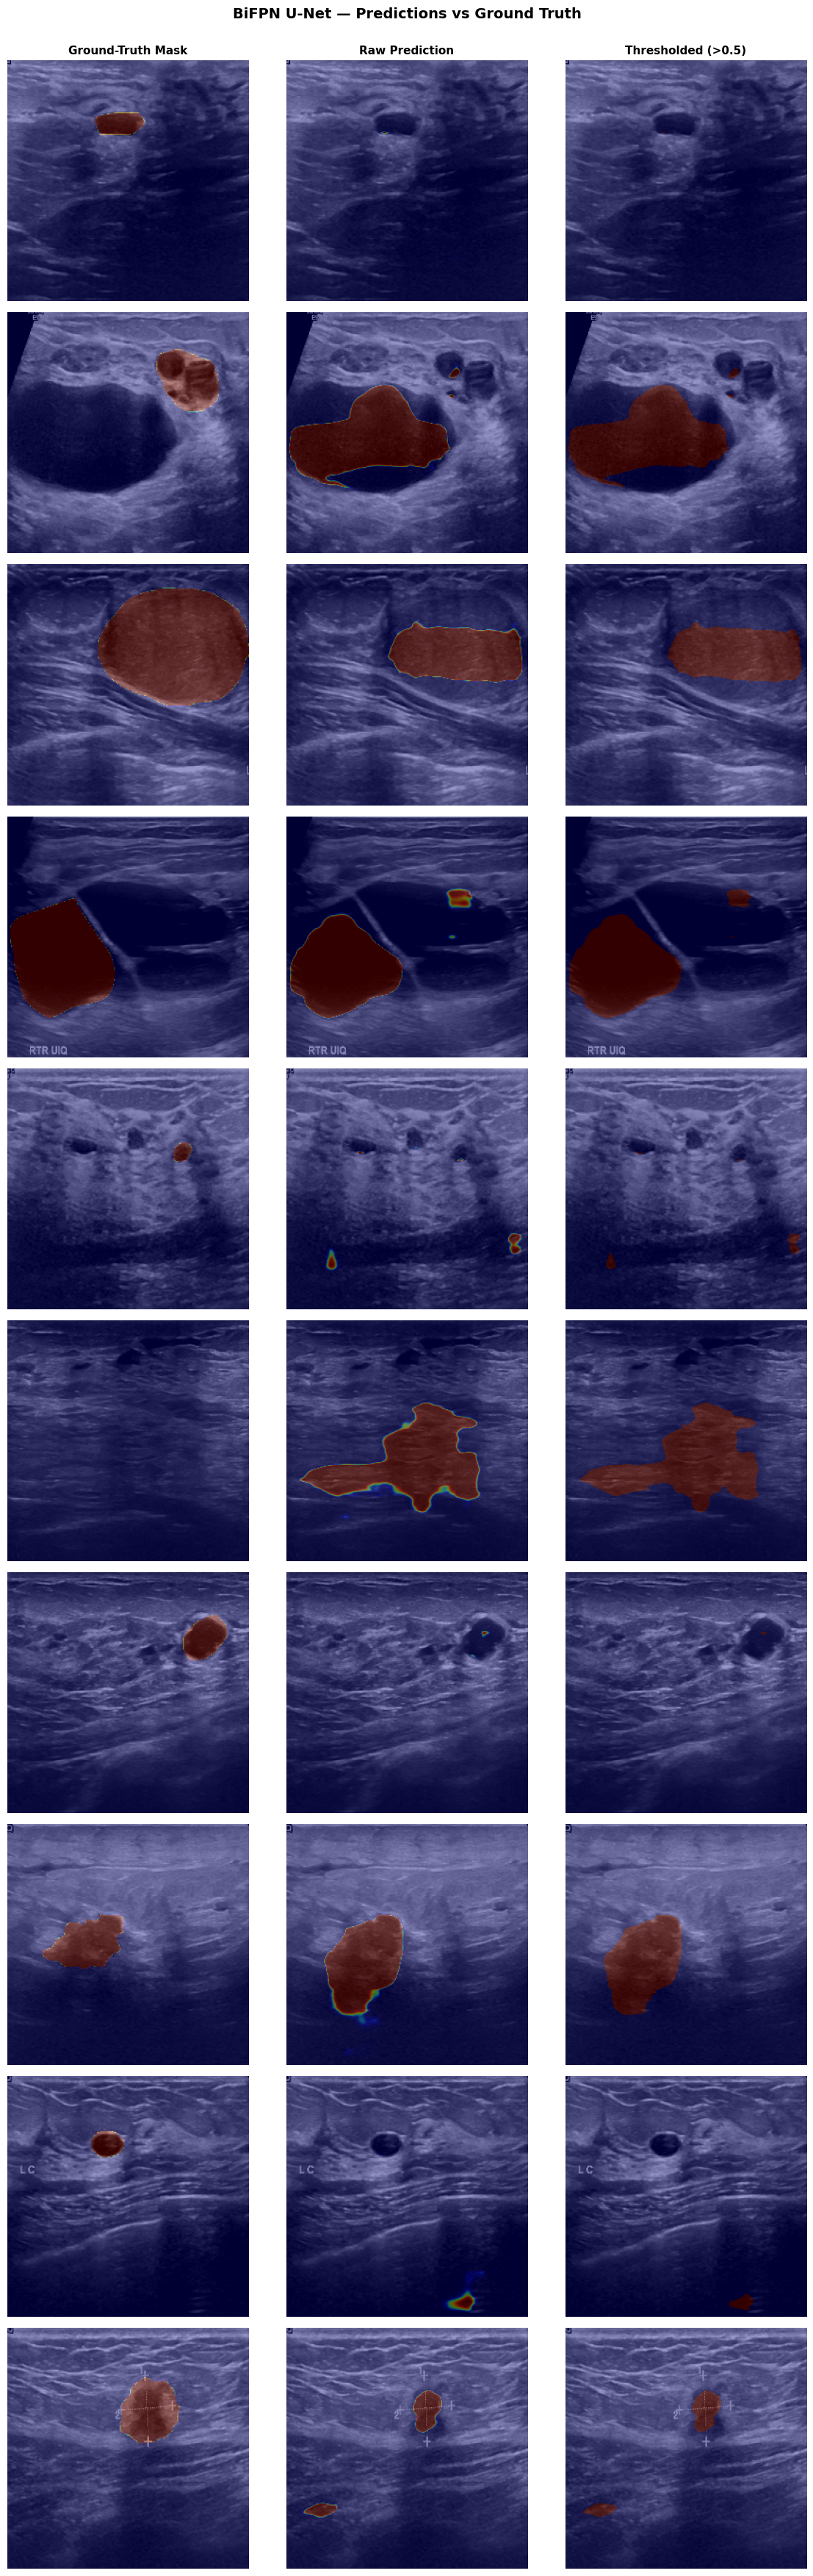

Saved → images/output/prediction_visualization.png


In [28]:
NUM_VIS = 10
np.random.seed(RANDOM_SEED)
vis_idx = np.random.randint(len(images), size=NUM_VIS)

# Single forward pass for all samples
vis_images = images[vis_idx]
vis_masks  = masks[vis_idx]
vis_preds  = model2.predict(vis_images, batch_size=BATCH_SIZE, verbose=0)
vis_raw    = vis_preds['segmentation']
vis_bin    = (vis_raw > SEG_THRESHOLD).astype('float')

col_titles = ['Ground-Truth Mask', 'Raw Prediction', f'Thresholded (>{SEG_THRESHOLD})']
fig, axes  = plt.subplots(NUM_VIS, 3, figsize=(12, NUM_VIS * 3.5))

for row in range(NUM_VIS):
    for col, mask_to_show in enumerate([vis_masks[row], vis_raw[row], vis_bin[row]]):
        plt.sca(axes[row, col])
        show_mask(vis_images[row], mask_to_show)
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=11, fontweight='bold')

plt.suptitle("BiFPN U-Net — Predictions vs Ground Truth", fontsize=14,
             fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_visualization.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print(f"Saved → {OUTPUT_DIR}/prediction_visualization.png")


## 12. Inference Demo

Run the BiFPN model on a **single image** to get both a segmentation mask and a class label.
Change `DEMO_CLASS` and `DEMO_SAMPLE_IDX` to try different examples.


Demo image : benign (100).png
  1/1 loaded


2026-06-19 18:57:32.781779: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:57:32.981594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:57:33.480825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:57:33.736148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 18:57:35.718000: E external/local_xla/xla/stream_

True class      : benign
Predicted class : benign  (confidence: 100.0%)


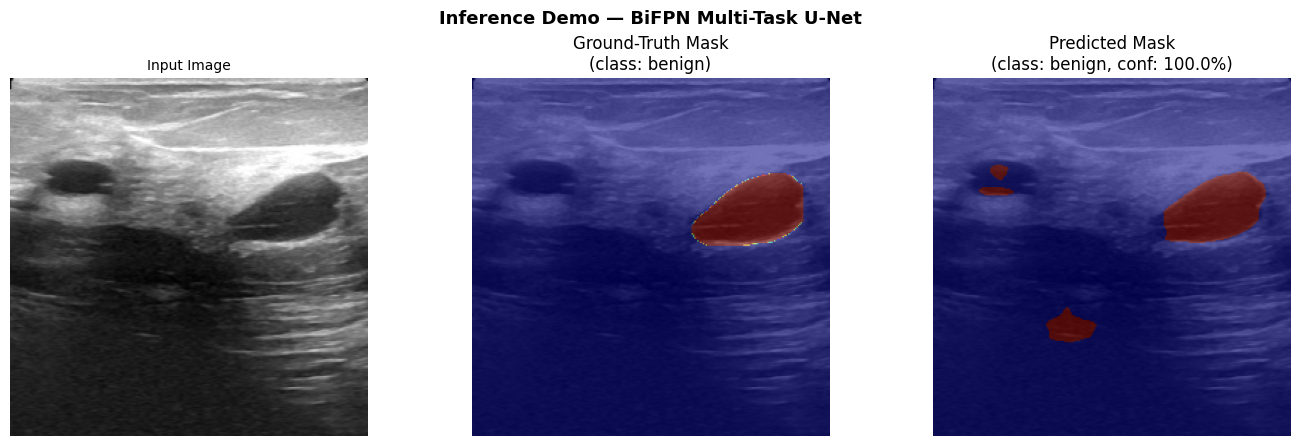

Saved → images/output/inference_demo.png


In [29]:
# ── Select demo image ─────────────────────────────────────────────────────────
DEMO_CLASS      = 'benign'   # 'benign' | 'malignant' | 'normal'
DEMO_SAMPLE_IDX = 2          # index within that class

demo_idx        = class_indices[DEMO_CLASS][DEMO_SAMPLE_IDX]
DEMO_IMAGE_PATH = image_paths[demo_idx]
DEMO_GT_MASK    = masks[demo_idx]
print(f"Demo image : {os.path.basename(DEMO_IMAGE_PATH)}")

# ── Forward pass ──────────────────────────────────────────────────────────────
demo_input = load_images([DEMO_IMAGE_PATH], IMG_SIZE)
preds      = model2.predict(demo_input, verbose=0)

raw_mask        = preds["segmentation"][0]
binary_mask     = (raw_mask > SEG_THRESHOLD).astype(np.uint8)
pred_class_idx  = np.argmax(preds["classification"], axis=1)[0]
confidence      = preds["classification"][0, pred_class_idx]
predicted_class = CLASS_NAMES[pred_class_idx]
true_class      = DEMO_CLASS

print(f"True class      : {true_class}")
print(f"Predicted class : {predicted_class}  (confidence: {confidence:.1%})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

plt.sca(axes[0])
show_image(demo_input[0], title="Input Image")

plt.sca(axes[1])
show_mask(demo_input[0], DEMO_GT_MASK, alpha=0.55)
plt.title(f"Ground-Truth Mask\n(class: {true_class})")

plt.sca(axes[2])
show_mask(demo_input[0], binary_mask, alpha=0.55)
plt.title(f"Predicted Mask\n(class: {predicted_class}, conf: {confidence:.1%})")

plt.suptitle("Inference Demo — BiFPN Multi-Task U-Net", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'inference_demo.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved → {OUTPUT_DIR}/inference_demo.png")
